In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd
import torch
import matplotlib.pyplot as plt, seaborn as sns
import matplotlib as mpl
from eval.data import load_and_split
from medal.model import AutoEncoder
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import fetch_openml
from pathlib import Path
import matplotlib as mpl

%load_ext autoreload
%autoreload 2

/home/bnc2119/.conda/envs/medal/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-06 23:56:20,973	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-05-06 23:56:23,321	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
# Set MEDAL_DATA_DIR to your drd_data directory
import os
PATH_PREFIX = os.environ.get('MEDAL_DATA_DIR', os.path.join(os.path.expanduser('~'), 'drd_data'))
# loading AE
def load_trained_ae(ckpt_path, input_dim, hidden_dims, latent_dim=2, batchnorm=False, 
                    activation=torch.nn.SELU, bottleneck_activation = None, dropout_rate=0.1):
    import sys, os
    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, "w")
    model = AutoEncoder(
        input_dim=input_dim,
        latent_dim=latent_dim,
        hidden_dims=hidden_dims,
        activation=activation,            
        bottleneck_activation=bottleneck_activation,
        use_batchnorm = batchnorm,
        dropout_rate = dropout_rate
    )
    sys.stdout = old_stdout

    sd = torch.load(ckpt_path, map_location="cpu")

    if isinstance(sd, dict) and "model" in sd and isinstance(sd["model"], dict):
        sd = sd["model"]
    elif isinstance(sd, dict) and "state_dict" in sd and isinstance(sd["state_dict"], dict):
        sd = sd["state_dict"]

    sd = {k.replace("module.", ""): v for k, v in sd.items()}
    
    missing, unexpected = model.load_state_dict(sd, strict=False)
    print(f"loaded params: {len(sd)} | missing={len(missing)} | unexpected={len(unexpected)}")
    if missing or unexpected:
        print("⚠️ Check architecture/keys. Example missing:", missing[:3], "unexpected:", unexpected[:3])

    model.eval()
    return model

In [3]:
mnist_distill0 = []
mnist_distill0_embeddings = []
mnist_per_sample_distill0 = []
from sklearn.model_selection import train_test_split
X, X_test, y, y_test = load_and_split("mnist", test_size=0.2, seed=0, labels=True)
X, _, y, _ = train_test_split(X, y, test_size=0.2, random_state=0)
teacher_embed = np.load(Path(PATH_PREFIX) / f'embeddings2/mnist_tsne_18_0_train.npy')
for c in range(3):
    student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/inter/mnist/medal_tsne2_18_tc0_0_ckpts/band{c}.pt",
            input_dim=784,
            hidden_dims=[512, 512, 512, 512],
            latent_dim=2)
    
    _, student_embed = student(torch.tensor(X, dtype=torch.float32))
    train_distill = np.mean((student_embed.detach().numpy() - teacher_embed)**2)
    per_sample_train_distill = np.mean((student_embed.detach().numpy() - teacher_embed)**2, axis=1)
    mnist_distill0.append(train_distill)
    mnist_distill0_embeddings.append(student_embed.detach().numpy())
    mnist_per_sample_distill0.append(per_sample_train_distill)

student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/inter/mnist/medal_tsne2_18_tc0_0_ckpts/final.pt",
        input_dim=784,
        hidden_dims=[512, 512, 512, 512],
        latent_dim=2)

_, student_embed = student(torch.tensor(X, dtype=torch.float32))
train_distill = np.mean((student_embed.detach().numpy() - teacher_embed)**2)
per_sample_train_distill = np.mean((student_embed.detach().numpy() - teacher_embed)**2, axis=1)
mnist_distill0.append(train_distill)
mnist_distill0_embeddings.append(student_embed.detach().numpy())
mnist_per_sample_distill0.append(per_sample_train_distill)

/tmp/ipykernel_24227/1894101382.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


/tmp/ipykernel_24227/1791026307.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("BuPu")


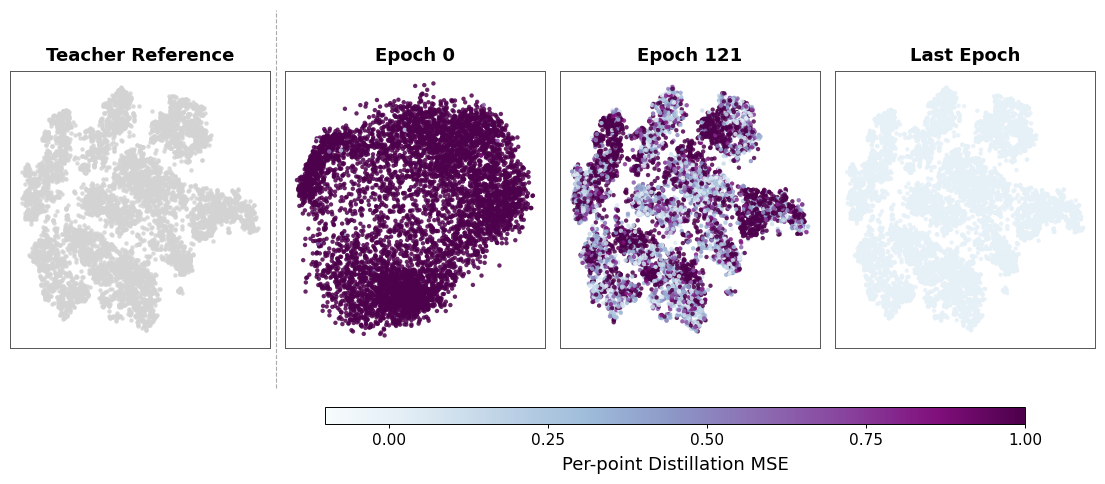

In [31]:
plt.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Arial", "Helvetica Neue", "DejaVu Sans"],
    "font.size":          11,
    "axes.labelsize":     12,
    "axes.titlesize":     13,
    "axes.linewidth":     0.8,
    "xtick.major.width":  0.8,
    "ytick.major.width":  0.8,
    "figure.titlesize":   15,
    "figure.titleweight": "bold",
})

cmap = plt.cm.get_cmap("BuPu")
norm = mpl.colors.Normalize(vmin=-0.1, vmax=1)

POINT_SIZE   = 10    
POINT_ALPHA  = 0.85
LINEWIDTH    = 0.0   

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), sharey=True)
fig.subplots_adjust(wspace=0.06)

scatter_kw = dict(palette=cmap, hue_norm=norm, legend=None,
                  s=POINT_SIZE, alpha=POINT_ALPHA, linewidth=LINEWIDTH)
teacher_scatter_kw = dict(legend=None,
                  s=POINT_SIZE, alpha=POINT_ALPHA, linewidth=LINEWIDTH)

# ── Panels ──────────────────────────────────────────────────────────────────
panel_data = [
    (teacher_embed,                       np.zeros(len(teacher_embed)),        "Teacher Reference"),
    (mnist_distill0_embeddings[0],        mnist_per_sample_distill0[0],        "Epoch 0"),
    (mnist_distill0_embeddings[2],        mnist_per_sample_distill0[2],        "Epoch 121"),
    (mnist_distill0_embeddings[-1],       mnist_per_sample_distill0[-1],       "Last Epoch"),
]

for i, (ax, (embed, hue, title)) in enumerate(zip(axes, panel_data)):
    if i == 0:
        sns.scatterplot(x=embed[:, 0], y=embed[:, 1], color='#D3D3D3', ax=ax, **teacher_scatter_kw)        
    else:    
        sns.scatterplot(x=embed[:, 0], y=embed[:, 1], hue=hue, ax=ax, **scatter_kw)

    ax.set_title(title, fontsize=13, fontweight="bold", pad=7)
    ax.set_xticks([]);  ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_linewidth(0.7)
        spine.set_color("#555555")

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cax = fig.add_axes([0.35, -0.10, 0.50, 0.045])   # [left, bottom, width, height]
cb  = fig.colorbar(sm, cax=cax, orientation="horizontal")
cb.set_label("Per-point Distillation MSE", fontsize=13, labelpad=6)
cb.ax.tick_params(labelsize=11, width=0.7, length=3)
cb.outline.set_linewidth(0.7)
cb.set_ticks([0, 0.25, 0.50, 0.75, 1.0])

fig.add_artist(mpl.lines.Line2D(
    [0.315, 0.315], [0.0, 1.05], 
    transform=fig.transFigure,
    color="#aaaaaa", linewidth=0.8, linestyle="--"
))

plt.show()

In [3]:
mnist_res_dict = []
mnist_test_res_dict = []
from sklearn.model_selection import train_test_split
X, X_test, y, y_test = load_and_split("mnist", test_size=0.2, seed=0, labels=True)
X, X_val, y, y_val = train_test_split(X, y, test_size=0.2, random_state=0)
for s in range(5):
    for c in np.unique(np.logspace(np.log10(2), np.log10(100), 10).astype(int)):
        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/mnist/vanillaAE_{c}_tc0_{s}_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[512, 512, 512, 512],
                latent_dim=c, batchnorm=False)
        
        student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        mnist_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "vanilla AE"})
        x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
        test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        mnist_test_res_dict.append({"n_components": c, "recon_loss": test_recon, "seed": s, "method": "vanilla AE"})

        pca = PCA(n_components=c).fit(X)
        X_hat = pca.inverse_transform(pca.transform(X))
        train_recon = ((X - X_hat)**2).mean()
        mnist_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "PCA"})
        X_hat = pca.inverse_transform(pca.transform(X_test))
        test_recon = ((X_test - X_hat)**2).mean()
        mnist_test_res_dict.append({"n_components": c, "recon_loss": test_recon, "seed": s, "method": "PCA"})

        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/mnist/medal_pca{c}_tc0_{s}_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[512, 512, 512, 512],
                latent_dim=c, batchnorm=False)
        student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        mnist_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "MEDAL (PCA teacher)"})
        x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
        test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        mnist_test_res_dict.append({"n_components": c, "recon_loss": test_recon, "seed": s, "method": "MEDAL (PCA teacher)"})


        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/mnist/linearAE_pca{c}_tc0_{s}_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[512, 512, 512, 512],
                latent_dim=c, activation=None, batchnorm=False, dropout_rate=0)
        
        student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        mnist_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "MEDAL Linear AE (PCA teacher)"})
        x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
        test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        mnist_test_res_dict.append({"n_components": c, "recon_loss": test_recon, "seed": s, "method": "MEDAL Linear AE (PCA teacher)"})

/tmp/ipykernel_9977/1894101382.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0


/tmp/ipykernel_9977/1894101382.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


/tmp/ipykernel_9977/1894101382.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


...

loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


/tmp/ipykernel_9977/1894101382.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


/tmp/ipykernel_9977/1894101382.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


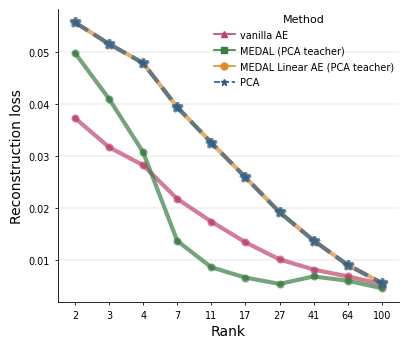

In [4]:

import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.family':            'sans-serif',
    'font.sans-serif':        ['Arial', 'Liberation Sans', 'DejaVu Sans'],
    'font.size':              8,
    'axes.labelsize':         8,
    'axes.titlesize':         9,
    'xtick.labelsize':        7,
    'ytick.labelsize':        7,
    'legend.fontsize':        7,
    'legend.title_fontsize':  8,
    'axes.linewidth':         0.6,
    'xtick.major.width':      0.6,
    'ytick.major.width':      0.6,
    'xtick.major.size':       2.5,
    'ytick.major.size':       2.5,
    'lines.linewidth':        1.2,
    'lines.markersize':       3.5,
    'pdf.fonttype':           42,
    'ps.fonttype':            42,
})

analysis      = pd.DataFrame(mnist_res_dict)
analysis      = analysis[~analysis.method.isin(["MEDAL + UMAP", "MEDAL + Spectral"])]
analysis_test = pd.DataFrame(mnist_test_res_dict)
analysis_test = analysis_test[~analysis_test.method.isin(["MEDAL + UMAP", "MEDAL + Spectral"])]

palette = {
    'vanilla AE':            '#C0446A',
    'MEDAL (PCA teacher)':           '#3A7D44',
    'MEDAL Linear AE (PCA teacher)': '#E08B2A',
    'PCA':                   '#2C5F8A',
}

markers = {
    'vanilla AE':            '^',
    'MEDAL (PCA teacher)':           's',
    'MEDAL Linear AE (PCA teacher)': 'o',
    'PCA':                   '*',
}

fig, ax = plt.subplots(1, 1, figsize=(4, 3.4))

sns.pointplot(
    data=analysis[analysis['method'] != 'PCA'],
    x='n_components', y='recon_loss',
    hue='method', palette=palette,
    errorbar='se', err_kws={'linewidth': 0.6},
    markersize=3.5, linewidth=3,
    dodge=False, legend=False, ax=ax, alpha=0.7
)
sns.pointplot(
    data=analysis[analysis['method'] == 'PCA'],
    x='n_components', y='recon_loss',
    hue='method', palette=palette,
    markersize=7, linewidth=3,alpha=0.7,
    legend=False, ax=ax,
    markers='*', linestyles='--',
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax.grid(axis='y', linewidth=0.35, color='gray', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
ax.set_xlabel('Rank', labelpad=3, fontsize=10)
ax.set_ylabel('Reconstruction loss', labelpad=3, fontsize=10)

legend_handles = []
for method, color in palette.items():
    ls = '--' if method == 'PCA' else '-'
    mk = markers[method]
    legend_handles.append(
        Line2D([0], [0], color=color, marker=mk,
               markersize=5, linewidth=1.2,
               linestyle=ls, label=method)
    )

ax.legend(
    handles=legend_handles,
    loc='upper right',
    frameon=False,
    title='Method',
    handlelength=2.2,
    handletextpad=0.5,
    borderpad=0,
    labelspacing=0.6,
)

plt.tight_layout(pad=0.5)
plt.show()

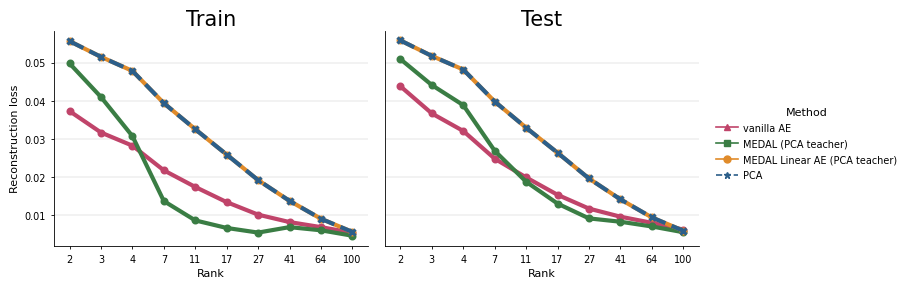

In [8]:
analysis      = pd.DataFrame(mnist_res_dict)
analysis      = analysis[~analysis.method.isin(["MEDAL + UMAP", "MEDAL + Spectral"])]
analysis_test = pd.DataFrame(mnist_test_res_dict)
analysis_test = analysis_test[~analysis_test.method.isin(["MEDAL + UMAP", "MEDAL + Spectral"])]

fig, axes = plt.subplots(1, 2, figsize=(7, 2.8), sharey=True)

for ax, data, title in zip(axes,
                            [analysis, analysis_test],
                            ['Train', 'Test']):
    # Non-PCA methods
    sns.pointplot(
        data=data[data['method'] != 'PCA'],
        x='n_components', y='recon_loss',
        hue='method', palette=palette,
        errorbar='se', err_kws={'linewidth': 0.6},
        markersize=3.5, linewidth=3,
        dodge=False, legend=False, ax=ax,
    )

    sns.pointplot(
        data=data[data['method'] == 'PCA'],
        x='n_components', y='recon_loss',
        hue='method', palette=palette,
        markersize=4, linewidth=3,
        legend=False, ax=ax,
        markers='x', linestyles='--',
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.6)
    ax.spines['bottom'].set_linewidth(0.6)

    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    ax.grid(axis='y', linewidth=0.35, color='gray', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)

    ax.set_title(title, pad=4, fontsize=15)
    ax.set_xlabel("Rank", labelpad=3)

axes[0].set_ylabel("Reconstruction loss", labelpad=3)
axes[1].set_ylabel("")
axes[1].tick_params(axis='y', left=False)

legend_handles = []
for method, color in palette.items():
    ls = '--' if method == 'PCA' else '-'
    mk = markers[method]
    legend_handles.append(
        Line2D([0], [0],
               color=color, marker=mk,
               markersize=5, linewidth=1.2,
               linestyle=ls, label=method)
    )

fig.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
    title='Method',
    handlelength=2.2,
    handletextpad=0.5,
    borderpad=0,
    labelspacing=0.6,
)

plt.tight_layout(pad=0.5, w_pad=1.5)
plt.show()